<a href="https://colab.research.google.com/github/mkweisbr/Medical-Insurance-Cost-Prediction/blob/main/Health_Insurance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files

# This will open a file browser to select your CSV
uploaded = files.upload()

Saving insurance.csv to insurance.csv


In [3]:
# Step 0: Imports
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load CSV
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max

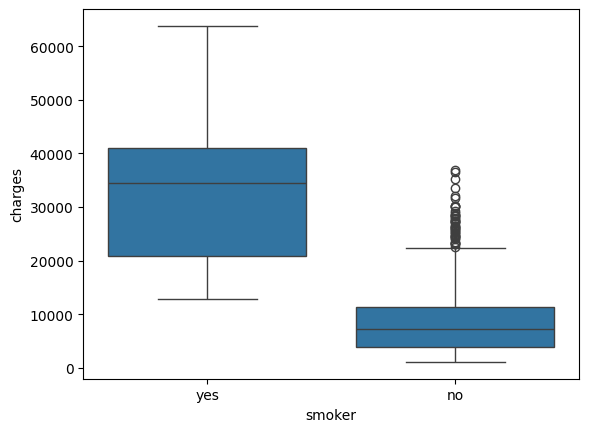

In [ ]:
print(df.info())
print(df.describe())

# Boxplot: Charges vs smoker
sns.boxplot(x='smoker', y='charges', data=df)
plt.show()

In [5]:
# Convert categorical columns into dummies, drop first to avoid multicollinearity
df_encoded = pd.get_dummies(df, columns=['sex','smoker','region'], drop_first=True)

# Verify column names
print(df_encoded.columns)

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='object')


In [6]:
df_encoded['age_c'] = df_encoded['age'] - df_encoded['age'].mean()
df_encoded['bmi_c'] = df_encoded['bmi'] - df_encoded['bmi'].mean()
df_encoded['children_c'] = df_encoded['children'] - df_encoded['children'].mean()

df_encoded['age_bmi'] = df_encoded['age_c'] * df_encoded['bmi_c']
df_encoded['smoker_bmi'] = df_encoded['smoker_yes'] * df_encoded['bmi_c']
df_encoded['age_children'] = df_encoded['age_c'] * df_encoded['children_c']

In [8]:
# Features and target
X = df_encoded.drop('charges', axis=1)

# Drop ONLY the original (uncentered) variables
X = X.drop(['age', 'bmi', 'children'], axis=1)

y = df_encoded['charges']

# Add constant
X = sm.add_constant(X)

# Ensure numeric
X = X.astype(float)
y = y.astype(float)

# Fit model
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.841
Model:                            OLS   Adj. R-squared:                  0.840
Method:                 Least Squares   F-statistic:                     638.1
Date:                Fri, 10 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:30:45   Log-Likelihood:                -13247.
No. Observations:                1338   AIC:                         2.652e+04
Df Residuals:                    1326   BIC:                         2.658e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             9377.1942    309.562  

In [9]:
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_data.sort_values(by='VIF', ascending=False)

,feature,VIF
0,const,5.457045
4,region_southeast,1.656924
5,region_southwest,1.530975
3,region_northwest,1.521407
7,bmi_c,1.389551
10,smoker_bmi,1.288362
6,age_c,1.097415
11,age_children,1.082519
1,sex_male,1.014092
2,smoker_yes,1.012744


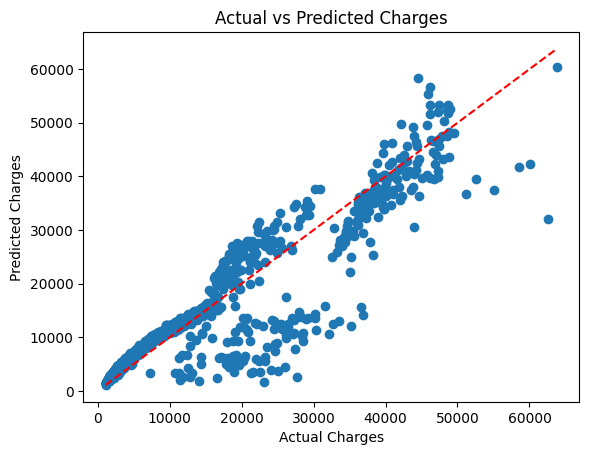

In [12]:
plt.scatter(y, model.fittedvalues)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()

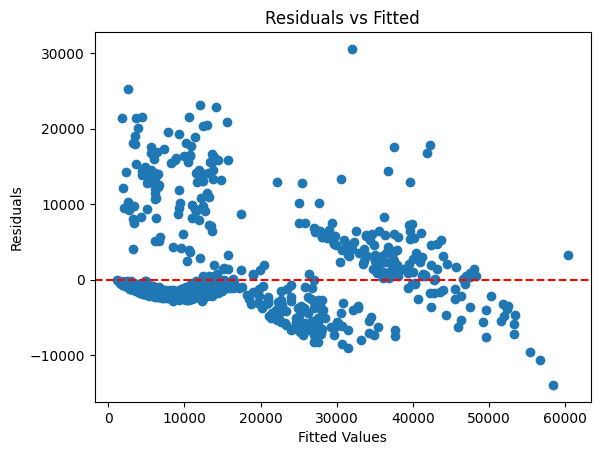

In [11]:
plt.scatter(model.fittedvalues, model.resid)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()